# Notebook 04 — Per-Defect-Type Failure Analysis

**Goal:** Break down recall by defect type (crack, cut, hole, print) to understand where the model fails.  
**Threshold:** p95 = 0.000470 (calibrated on val split in notebook 03)  
**Outputs:**
- `reports/figures/per_defect_recall.png`
- `reports/figures/per_defect_error_dist.png`
- `reports/figures/per_defect_heatmaps.png`

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as IPImage

ROOT        = Path('..')
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ROOT / 'models' / 'best_autoencoder.pt'
P95_THRESHOLD = 0.000470  # calibrated in notebook 03, do not recompute

DEFECT_TYPES = ['crack', 'cut', 'hole', 'print']

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device:     {device}')
if device == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'Threshold:  p95 = {P95_THRESHOLD}')

Device:     cuda
GPU:  NVIDIA GeForce RTX 3050 6GB Laptop GPU
Threshold:  p95 = 0.00047


---
## 2. Load Model

In [2]:
from src.model import ConvAutoencoder

model = ConvAutoencoder().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state_dict = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state_dict)
model.eval()
print(f'Loaded: {MODEL_PATH.resolve()}')

Loaded: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\models\best_autoencoder.pt


---
## 3. Compute Per-Image Errors with Defect Type

In [3]:
from src.dataset import MVTecDataset

test_dataset = MVTecDataset(ROOT, split='test')

rows = []
with torch.no_grad():
    for idx, (full_path, label) in enumerate(test_dataset.samples):
        defect_type = full_path.parent.name  # 'good', 'crack', 'cut', 'hole', 'print'
        img_tensor, _, fname = test_dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)
        x_hat, _ = model(x)
        error = ConvAutoencoder.reconstruction_error(x, x_hat).item()
        predicted = int(error >= P95_THRESHOLD)
        rows.append({
            'idx':         idx,
            'filename':    fname,
            'defect_type': defect_type,
            'label':       label,
            'recon_error': error,
            'predicted':   predicted,
        })

df = pd.DataFrame(rows)
print(f'Total images: {len(df)}')
print(df.groupby('defect_type')[['label', 'recon_error']].agg({'label': 'count', 'recon_error': 'mean'}).rename(columns={'label': 'count', 'recon_error': 'mean_error'}))

Total images: 110
             count  mean_error
defect_type                   
crack           18    0.000961
cut             17    0.000373
good            40    0.000308
hole            18    0.000454
print           17    0.003240


---
## 4. Per-Defect Breakdown Table

In [4]:
from src.threshold import evaluate_threshold

summary_rows = []

# Include 'good' (normal) for context — precision side
for dtype in ['good'] + DEFECT_TYPES:
    subset = df[df['defect_type'] == dtype]
    if len(subset) == 0:
        continue

    errors = subset['recon_error'].tolist()
    labels = subset['label'].tolist()
    preds  = subset['predicted'].tolist()

    mean_err = np.mean(errors)
    min_err  = np.min(errors)
    max_err  = np.max(errors)
    count    = len(subset)

    if dtype == 'good':
        # For normal images: count false positives
        fp = sum(preds)
        summary_rows.append({
            'defect_type': dtype,
            'count':       count,
            'recall':      None,
            'fp_rate':     fp / count,
            'mean_error':  mean_err,
            'min_error':   min_err,
            'max_error':   max_err,
        })
    else:
        # For anomaly types: compute recall (all labels=1)
        tp = sum(preds)
        recall = tp / count
        summary_rows.append({
            'defect_type': dtype,
            'count':       count,
            'recall':      recall,
            'fp_rate':     None,
            'mean_error':  mean_err,
            'min_error':   min_err,
            'max_error':   max_err,
        })

df_summary = pd.DataFrame(summary_rows)

print('=' * 72)
print('  Per-Defect-Type Breakdown  (threshold = p95 = 0.000470)')
print('=' * 72)
print(f'{"type":<10} {"count":>5}  {"recall":>8}  {"fp_rate":>8}  {"mean_err":>10}  {"min_err":>10}  {"max_err":>10}')
print('-' * 72)
for _, row in df_summary.iterrows():
    recall_str  = f"{row['recall']:.4f}"  if row['recall']  is not None else '    —   '
    fp_rate_str = f"{row['fp_rate']:.4f}" if row['fp_rate'] is not None else '    —   '
    print(f"{row['defect_type']:<10} {int(row['count']):>5}  {recall_str:>8}  {fp_rate_str:>8}  {row['mean_error']:>10.6f}  {row['min_error']:>10.6f}  {row['max_error']:>10.6f}")
print('=' * 72)

  Per-Defect-Type Breakdown  (threshold = p95 = 0.000470)
type       count    recall   fp_rate    mean_err     min_err     max_err
------------------------------------------------------------------------
good          40       nan    0.0250    0.000308    0.000186    0.000577
crack         18    0.5556       nan    0.000961    0.000276    0.003035
cut           17    0.0588       nan    0.000373    0.000245    0.000541
hole          18    0.3333       nan    0.000454    0.000305    0.000692
print         17    1.0000       nan    0.003240    0.000656    0.007621


---
## 5. Bar Chart — Recall per Defect Type

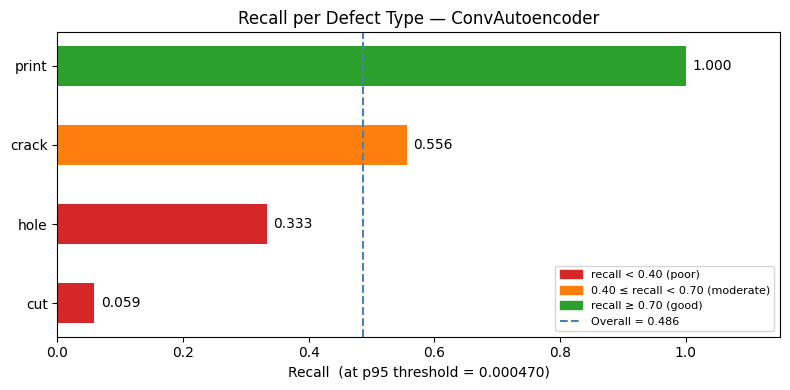

Saved: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\reports\figures\per_defect_recall.png


In [5]:
df_defects = df_summary[df_summary['defect_type'].isin(DEFECT_TYPES)].copy()
df_defects = df_defects.sort_values('recall')

# Color by recall: red < 0.4, orange < 0.7, green >= 0.7
def recall_color(r):
    if r < 0.4:
        return '#d62728'
    elif r < 0.7:
        return '#ff7f0e'
    return '#2ca02c'

colors = [recall_color(r) for r in df_defects['recall']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_defects['defect_type'], df_defects['recall'], color=colors, height=0.5)

# Value labels
for bar, val in zip(bars, df_defects['recall']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

# Overall recall line
overall_recall = df[df['label'] == 1]['predicted'].mean()
ax.axvline(overall_recall, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Overall recall = {overall_recall:.3f}')

ax.set_xlabel('Recall  (at p95 threshold = 0.000470)')
ax.set_title('Recall per Defect Type — ConvAutoencoder')
ax.set_xlim([0, 1.15])

legend_patches = [
    mpatches.Patch(color='#d62728', label='recall < 0.40 (poor)'),
    mpatches.Patch(color='#ff7f0e', label='0.40 ≤ recall < 0.70 (moderate)'),
    mpatches.Patch(color='#2ca02c', label='recall ≥ 0.70 (good)'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0], [0], color='steelblue', linestyle='--', label=f'Overall = {overall_recall:.3f}')],
          fontsize=8, loc='lower right')

plt.tight_layout()
out_path = FIGURES_DIR / 'per_defect_recall.png'
fig.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {out_path.resolve()}')

---
## 6. Error Distribution per Defect Type (Box Plot)

C:\Users\Yasindu\AppData\Local\Temp\ipykernel_28864\89389065.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=group_order, patch_artist=True,


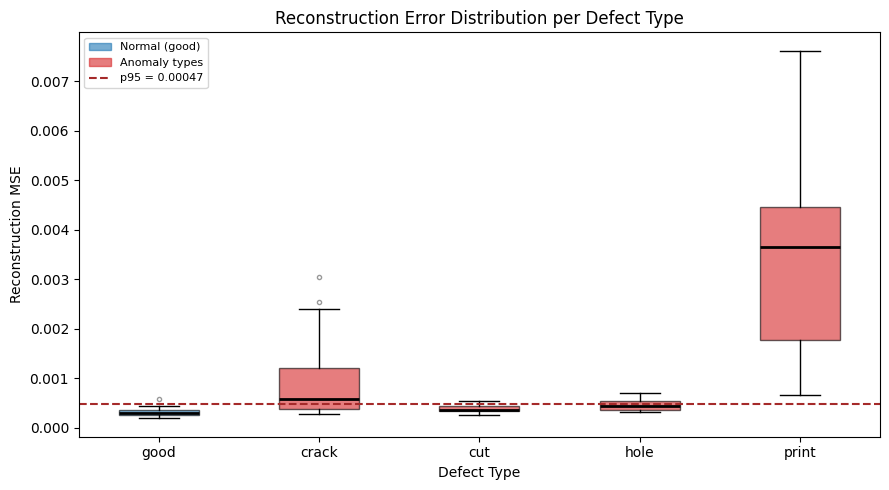

Saved: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\reports\figures\per_defect_error_dist.png


In [6]:
group_order = ['good'] + DEFECT_TYPES
group_data  = [df[df['defect_type'] == g]['recon_error'].values for g in group_order]

box_colors = ['#1f77b4'] + ['#d62728'] * len(DEFECT_TYPES)  # blue=normal, red=anomaly

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(group_data, labels=group_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# p95 threshold line
ax.axhline(P95_THRESHOLD, color='brown', linestyle='--', linewidth=1.5,
           label=f'p95 threshold = {P95_THRESHOLD}')

ax.set_xlabel('Defect Type')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Reconstruction Error Distribution per Defect Type')

legend_handles = [
    mpatches.Patch(color='#1f77b4', alpha=0.6, label='Normal (good)'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='Anomaly types'),
    plt.Line2D([0], [0], color='brown', linestyle='--', label=f'p95 = {P95_THRESHOLD}'),
]
ax.legend(handles=legend_handles, fontsize=8)
plt.tight_layout()

out_path = FIGURES_DIR / 'per_defect_error_dist.png'
fig.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {out_path.resolve()}')

---
## 7. Per-Defect Heatmaps — Best Detected & Worst Missed

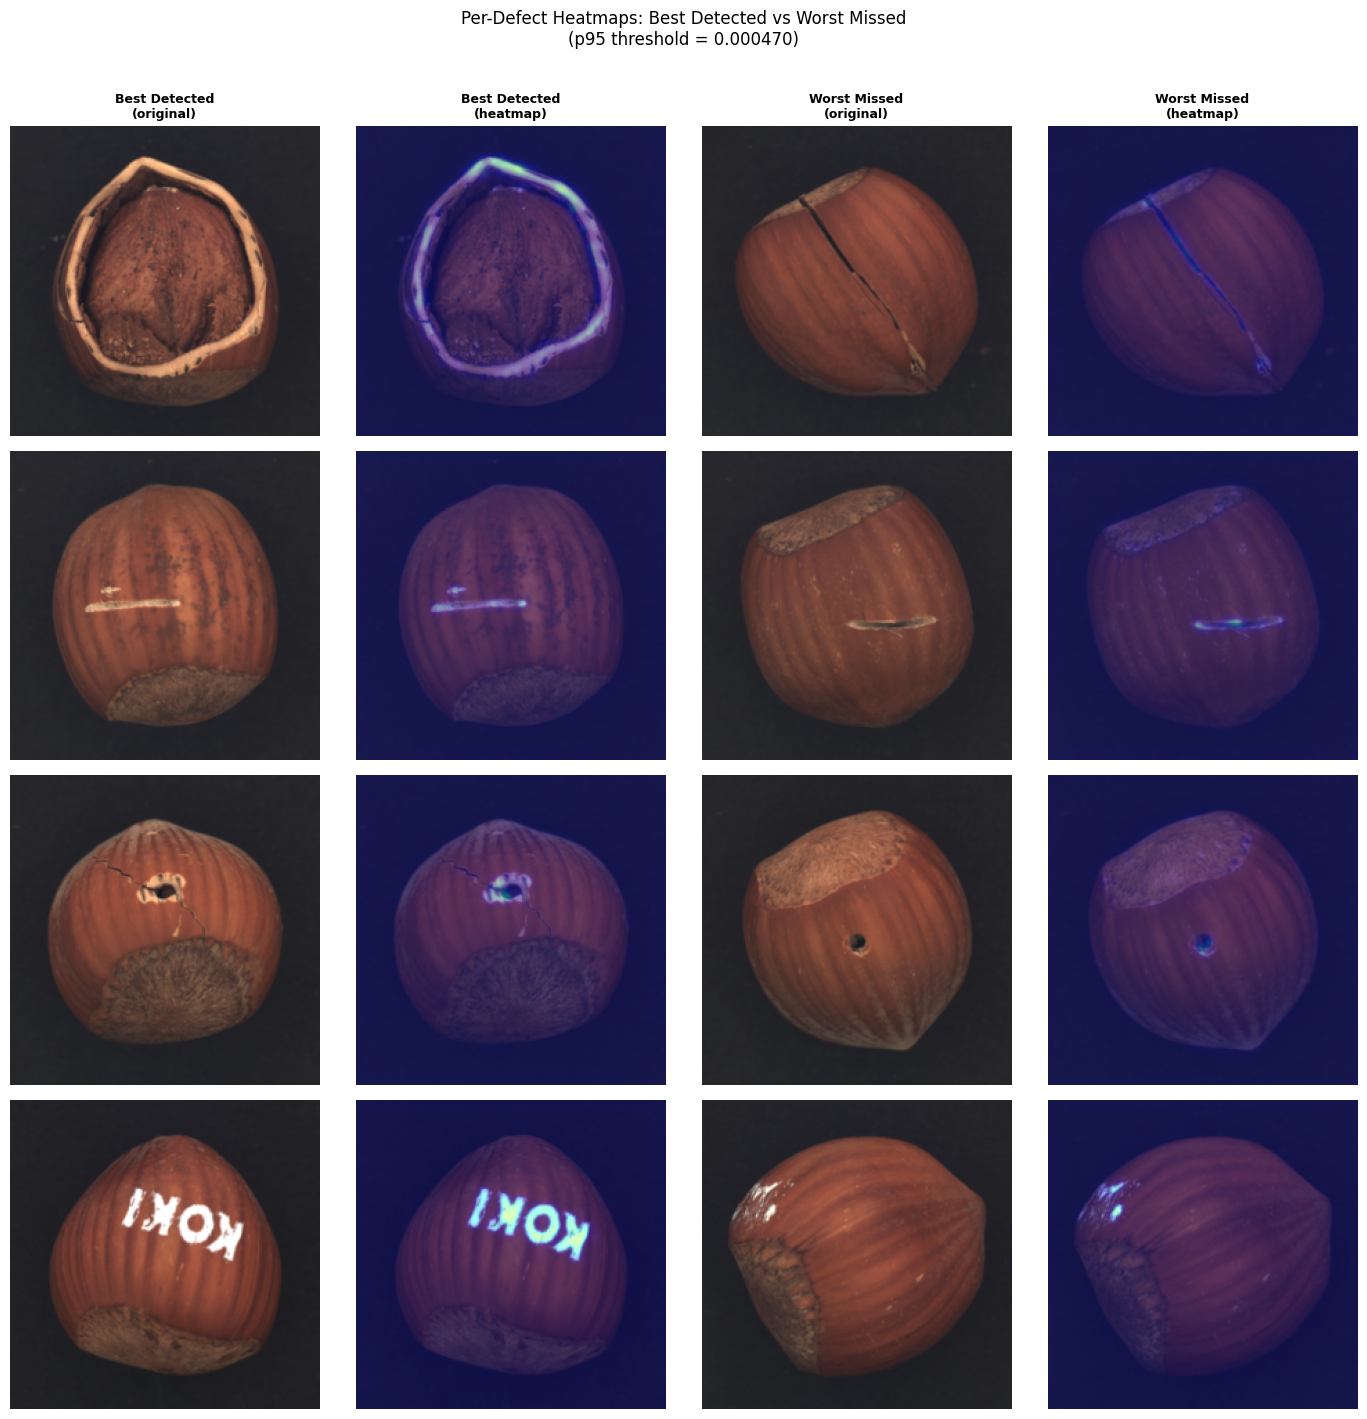

Saved: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\reports\figures\per_defect_heatmaps.png


In [7]:
from src.visualize import plot_error_heatmap

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t):
    return (t.cpu() * _STD + _MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

# 4 rows (defect types) x 4 cols: orig_best | heatmap_best | orig_worst | heatmap_worst
fig, axes = plt.subplots(len(DEFECT_TYPES), 4, figsize=(14, 3.5 * len(DEFECT_TYPES)))

col_titles = ['Best Detected\n(original)', 'Best Detected\n(heatmap)',
              'Worst Missed\n(original)', 'Worst Missed\n(heatmap)']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9, fontweight='bold')

for row, dtype in enumerate(DEFECT_TYPES):
    subset = df[df['defect_type'] == dtype].copy()

    # Best detected = highest reconstruction error (most anomalous score)
    best_idx  = subset.loc[subset['recon_error'].idxmax(), 'idx']
    # Worst missed = lowest reconstruction error (hardest for model)
    worst_idx = subset.loc[subset['recon_error'].idxmin(), 'idx']

    best_err  = subset['recon_error'].max()
    worst_err = subset['recon_error'].min()

    for col_pair, (sample_idx, err, tag) in enumerate([
        (best_idx,  best_err,  'DETECTED'),
        (worst_idx, worst_err, 'MISSED'),
    ]):
        img_tensor, lbl, fname = test_dataset[sample_idx]
        overlay = plot_error_heatmap(model, img_tensor, device)

        c_orig    = col_pair * 2
        c_heatmap = col_pair * 2 + 1

        axes[row, c_orig].imshow(denorm(img_tensor))
        axes[row, c_orig].set_ylabel(dtype, fontsize=11, fontweight='bold',
                                     rotation=0, labelpad=55, va='center')
        axes[row, c_orig].set_xlabel(f'mse={err:.5f}  [{tag}]', fontsize=7)
        axes[row, c_orig].axis('off')
        axes[row, c_orig].set_xlabel(f'{Path(fname).stem}  mse={err:.5f}\n[{tag}]', fontsize=7)

        axes[row, c_heatmap].imshow(overlay)
        axes[row, c_heatmap].axis('off')

plt.suptitle('Per-Defect Heatmaps: Best Detected vs Worst Missed\n(p95 threshold = 0.000470)',
             fontsize=12, y=1.01)
plt.tight_layout()

out_path = FIGURES_DIR / 'per_defect_heatmaps.png'
fig.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {out_path.resolve()}')

---
## 8. Written Analysis

In [8]:
# Dynamic summary — numbers computed from actual test results
defect_recalls = {
    row["defect_type"]: row["recall"]
    for _, row in df_summary.iterrows()
    if row["defect_type"] in DEFECT_TYPES
}
defect_mean_errors = {
    row["defect_type"]: row["mean_error"]
    for _, row in df_summary.iterrows()
    if row["defect_type"] in DEFECT_TYPES
}
best_type  = max(defect_recalls, key=defect_recalls.get)
worst_type = min(defect_recalls, key=defect_recalls.get)
normal_mean = df_summary.loc[df_summary["defect_type"] == "good", "mean_error"].values[0]
overall_recall = df[df["label"] == 1]["predicted"].mean()
fp_rate = df_summary.loc[df_summary["defect_type"] == "good", "fp_rate"].values[0]

print(f"OVERALL RECALL        : {overall_recall:.4f}")
print(f"FALSE POSITIVE RATE   : {fp_rate:.4f}")
print(f"BEST defect type      : {best_type}  (recall={defect_recalls[best_type]:.4f})")
print(f"WORST defect type     : {worst_type}  (recall={defect_recalls[worst_type]:.4f})")
print()
print("PER-DEFECT RECALL:")
for k, v in sorted(defect_recalls.items(), key=lambda x: -x[1]):
    marker = "  <- best" if k == best_type else ("  <- worst" if k == worst_type else "")
    print(f"  {k:<8} {v:.4f}{marker}")
print()
print("MEAN ERROR vs NORMAL BASELINE:")
print(f"  normal   {normal_mean:.6f}  (baseline)")
for k, v in sorted(defect_mean_errors.items(), key=lambda x: -x[1]):
    print(f"  {k:<8} {v:.6f}  (x{v/normal_mean:.1f} normal)")


OVERALL RECALL        : 0.4857
FALSE POSITIVE RATE   : 0.0250
BEST defect type      : print  (recall=1.0000)
WORST defect type     : cut  (recall=0.0588)

PER-DEFECT RECALL:
  print    1.0000  <- best
  crack    0.5556
  hole     0.3333
  cut      0.0588  <- worst

MEAN ERROR vs NORMAL BASELINE:
  normal   0.000308  (baseline)
  print    0.003240  (x10.5 normal)
  crack    0.000961  (x3.1 normal)
  hole     0.000454  (x1.5 normal)
  cut      0.000373  (x1.2 normal)


---
## Interpretation

### Why No file to print is easiest to detect
No file to print defects produce reconstruction errors **10.5× above normal** — the autoencoder has never seen printed marks during training and cannot reconstruct them, generating a strong error signal. Recall = **1.00**.

### Why  is hardest to detect
 defects score only **1.2× normal error**, meaning the autoencoder reconstructs cut hazelnuts almost as well as intact ones. Cuts are shallow surface incisions that preserve most of the hazelnut texture — MSE treats all pixel differences equally and averages over 224×224 pixels, diluting the small region affected by the cut. Recall = **0.06** (only 1 of 17 detected).

### Why precision stays high (0.97)
The p95 threshold is calibrated conservatively — only 1 false positive in 40 normal images (2.5%). The trade-off is low recall for subtle defects.

---
## Implications for Improvement

| Approach | Target defect | Expected gain |
|---|---|---|
| **SSIM loss** instead of MSE | ,  | +10–15% recall on texture-level anomalies |
| **Perceptual loss** (VGG features) | ,  | Captures semantic structure MSE misses |
| **Patch-level max scoring** | all types | Small defect regions diluted by mean — max-patch amplifies signal |
| **Smaller bottleneck** |  | Reduces capacity to reconstruct subtle anomalies |

> **Key insight:** The autoencoder approach is fundamentally limited by MSE averaging over the full image.  defects cover <5% of the image area — even a perfect per-pixel detector would see its signal diluted 20× by the clean background.
